# q-Dependent BSE Calculations
**by <span style="color:darkgreen">Christian Vorwerk</span> & <span style="color:darkgreen">Caterina Cocchi</span> for [<span style="color:darkgoldenrod">exciting *sodium*</span>](https://www.exciting-code.org/sodium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Megha Arya</span> and <span style="color:darkgreen">Mara Voiculescu</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial you will learn how to perform Bethe-Salpeter equation (**BSE**) calculations to obtain x-ray and electron scattering spectra for finite momentum transfer. As an example, the valence and core scattering spectra of LiF are calculated.

<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
[1. Theoretical Background](#1)
    
[2. Preliminary Step: Ground-State Calculation](#2)
    
[3. Optical BSE Calculation for Finite Momentum Values](#3)
    
[4. X-Ray BSE Calculation for Finite Momentum Values](#4)
    
[5. Exercise](#5)
    
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Theoretical Background</span>

<hr style="border:1px solid #DDD"> </hr>

<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Electron and X-Ray Scattering Spectroscopy</span></strong>
 
<hr style="border:1px solid #DDD"> </hr>    
    
</summary>  

The inelastic, non-resonant scattering of electrons or x-ray photons with the electrons of a system are measured in **angle-resolved electron energy-loss spectroscopy (AR-EELS)** and **inelastic X-ray scattering spectroscopy (IXS)**, respectively. Both spectroscopies probe the double differential cross section **(DDCS)** $\frac{\delta^{2}\sigma}{\delta\Omega\omega′}$, which describes the scattering probability of a particle with final energy $\omega′$ into the solid angle $\Omega$. For the scattering of x-ray photons, the **DDCS** is proportional to the **dynamical structure factor** *S*(**q**,$\Delta\omega$)

\begin{equation}
\tag{1}
\left.\frac{\delta^{2}\sigma}{\delta\Omega\omega′}\right\vert_{x-ray} \propto \mathit S(\mathbf q,\Delta\omega),
\end{equation}

where **q** = **k**<sub>i</sub> − **k**<sub>f</sub> is the momentum loss from the initial momentum **k**<sub>i</sub> to the final one **k**<sub>f</sub>, and $\Delta\omega=\omega_{i}−\omega_{f}$ is the corresponding energy loss.

For the scattering of electrons, the **DDCS** is proportional to the **electron energy loss function** $ \mathit L ( \mathbf q,\Delta\omega$):

\begin{equation}
\tag{2}
\left.\frac{\delta^{2}\sigma}{\delta\Omega\omega′}\right\vert_{electron} \propto \mathit L(\mathbf q,\Delta\omega),
\end{equation}

In linear response theory, both the dynamical structure factor and the loss function can be expressed in terms of the macroscopic dielectric function $\varepsilon_{M} (\mathbf q,\Delta\epsilon)$. We obtain

\begin{equation}
\tag{3}
\mathit S(\mathbf q, \Delta\omega) = -\frac{1}{\pi} \nu^{-1}(\mathbf q)ℑ \Big[\frac{1}{\varepsilon_{M} (\mathbf q,\Delta\omega)}\Big],
\end{equation}

where $\nu(\mathbf q)$ is the Coulomb potential, and

\begin{equation}
\tag{4}
\mathit L(\mathbf q, \Delta\omega) = -ℑ \Big[\frac{1}{\varepsilon_{M} (\mathbf q,\Delta\omega)}\Big].
\end{equation}

In the theory part of the tutorial **Excited states from BSE**, the calculation of the macroscopic dielectric function $\varepsilon_{M} (\omega)$ is discussed in detail. Further in-depth discussion of this theory can be found **[<span style="color:firebrick">here</span>](http://exciting.wdfiles.com/local--files/oxygen-q-dependent-bse/BSEtheory.pdf)**.

</details>

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Preliminary Step: Ground-State Calculation</span>

**<span style="color:firebrick">Important note:</span>** All input parameters are given in **atomic units**!

As a preliminary step to calculate excited-state properties from **BSE**, a ground-state calculation has to be performed. In this tutorial we consider as an example LiF. Create a directory named **run_LiF_BSE_q** as well as a sub-directory **GS** where the preliminary ground state calculation is performed.

In [1]:
%%bash
mkdir -p run_LiF_BSE_q && cd run_LiF_BSE_q
mkdir -p GS

Inside the **GS** sub-directory we create the input file for LiF. In the <code><span style="color:green">structure</span></code> element we include the lattice parameter and basis vectors of LiF, which has a rock-salt cubic lattice, as well as the positions of the Li and F atoms. In the <code><span style="color:green">groundstate</span></code> element, we include a **10**×**10**×**10** **k**-point mesh (<code><span style="color:mediumblue">ngridk</span></code>) and a value of **<span style="color:firebrick">14.0</span>** for <code><span style="color:mediumblue">gmaxvr</span></code>. This value, which is larger than the default, is needed in view of the excited-state calculation.

Create a new file **input.xml** that looks like the following:

<span class="LiF_q_BSE"></span>
```xml
<input>
 
   <title>LiF-BSE: Ground-State Calculation</title>
 
   <structure speciespath="$EXCITINGROOT/species/">
      <crystal scale="7.608">
         <basevect>0.5 0.5 0.0</basevect>
         <basevect>0.5 0.0 0.5</basevect>
         <basevect>0.0 0.5 0.5</basevect>
      </crystal>
      <species speciesfile="F.xml">                                             
         <atom coord="0.5000  0.5000  0.5000" />                                
      </species>
      <species speciesfile="Li.xml">                                            
         <atom coord="0.0000  0.0000  0.0000" />                                
      </species>
   </structure>
 
   <groundstate
      do="fromscratch"
      ngridk="10  10  10"
      xctype="GGA_PBE_SOL"
      gmaxvr="14.0"/>
 
</input>

```

In [2]:
import os
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("q_dependent_bse_calculations", "LiF_q_BSE")

# Write out the input as an XML file:
with open('./run_LiF_BSE_q/GS/input.xml', "w") as fid:
    fid.write(input_str)

Replace the **$EXCITINGROOT** variable with the correct path by using the command:

In [3]:
%%bash
cd run_LiF_BSE_q/GS
python3 -m excitingscripts.setup.excitingroot
cd ../..

Now start the ground-state SCF calculation and check that it finishes gracefully. 

In [4]:
%%bash
cd run_LiF_BSE_q/GS
time $EXCITINGROOT/install/bin/exciting_smp input.xml
cd ../..

 ### Using specified input file: input.xml


   Elapsed time = 0m55s


In case of a successful run the files **STATE.OUT** and **EFERMI.OUT** should be present in the directory. These two files are needed as a starting point for the **BSE** calculation.

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Optical BSE Calculation for Finite Momentum Values</span>

To start the **BSE** calculations, move to the parent directory **LiF-BSE-q** and create a new folder with the name **BSE**:

In [5]:
%%bash
cd run_LiF_BSE_q
mkdir -p BSE

As anticipated, we need the files **STATE.OUT** and **EFERMI.OUT** obtained from the ground state calculation to be inside the new directory. Copy these two files from the **GS** folder into the **BSE** one.

In [6]:
%%bash
cd run_LiF_BSE_q/BSE
cp ../GS/{STATE.OUT,EFERMI.OUT,input.xml} ./
cd ../..

In this way, we can skip the ground-state calculation by setting <code><span style="color:mediumblue">do</span>=<span style="color:firebrick">"skip"</span></code> in the <code><span style="color:green">groundstate</span></code> element of the input file. To perform an excited-state calculation we must include the <code><span style="color:green">xs</span></code> element in the input file:
```xml
...
   <xs 
      xstype="BSE" 
      ngridk="4 4 4" 
      vkloff="0.097 0.273 0.493"
      ngridq="4 4 4"
      nempty="30"
      gqmax="3.0"
      broad="0.007"
      scissor="0.20947"
      tevout="true">
 
      <energywindow 
         intv="0.3 1.0" 
         points="1200"/>
 
      <screening 
         screentype="full"
         nempty="100"/>
 
      <BSE 
         bsetype="singlet"
         nstlbse="1 5 1 4"
         iqmtrange="1 3"/>
 
      <qpointset>
         <qpoint>0.00 0.0 0.00</qpoint>
         <qpoint>0.25 0.0 0.25</qpoint>
         <qpoint>0.50 0.0 0.50</qpoint>
      </qpointset>
 
   </xs>                 
...
     
```

The structure of the <code><span style="color:green">xs</span></code> element is nearly identical to the one described in the tutorial **Excited states from BSE**. The major changes are the following:

- The attribute <code><span style="color:mediumblue">iqmtrange</span></code> in the <code><span style="color:green">BSE</span></code> element defines the range of momentum transfer vectors **q** for which the calculation should be performed. The range has to lie within the boundaries of the the element <code><span style="color:green">qpointset</span></code>.
- In the <code><span style="color:green">qpointset</span></code> element, more <code><span style="color:green">qpoint</span></code> subelements are added, which define momentum transfer vectors for the calculations. Note that the **q**-vectors are provided in units of the reciprocal lattice vectors!

In [7]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingXSInput

parsed_input = ExcitingInputXML.from_xml('./run_LiF_BSE_q/BSE/input.xml')

xs = {'xstype': 'BSE', 'ngridk': [4, 4, 4], 'vkloff': [0.097, 0.273, 0.493], 'ngridq': [4, 4, 4], 'nempty': 30,
      'gqmax': 3.0, 'broad': 0.007, 'scissor': 0.20947, 'tevout': True,
      'energywindow': {'intv': [0.3, 1.0], 'points': 1200},
      'screening': {'screentype': 'full', 'nempty': 100},
      'BSE': {'bsetype': 'singlet', 'nstlbse': [1, 5, 1, 4], 'iqmtrange': [1, 3]},
      'qpointset': [[0.0, 0.0, 0.0], [0.25, 0.0, 0.25], [0.5, 0.0, 0.5]]}

parsed_input.xs = ExcitingXSInput(**xs)
parsed_input.groundstate.do = "skip"

parsed_input.write('./run_LiF_BSE_q/BSE/input.xml')

We can now run the BSE calculation with the following commands:

In [8]:
%%bash
cd run_LiF_BSE_q/BSE
time $EXCITINGROOT/install/bin/exciting_smp input.xml
cd ../..

 ### Using specified input file: input.xml


   Elapsed time = 10m20s


Once the calculation completes successfully (it will take a few minutes), a number of files and some folders will be generated in the working directory. Here, we are mostly interested in the calculated loss functions and dynamical structure factors, which can be found in the directory **LOSS**. The directory contains several files ending with **\_QMT00x.OUT**, where **x** is the index of the momentum transfer vector. For **q**=0, the loss function is a **3**×**3** tensor, and the optical components *L*<sub>xy</sub> (**q**=0, $\Delta\omega$) are written to the file ending with **\_OCxy.OUT**.

To plot the scattering spectra from your command line, execute the following commands.

In [9]:
%%bash
cd run_LiF_BSE_q/BSE
cp LOSS/LOSS_BSE-singlet-TDA-BAR_SCR-full_OC11.OUT   LOSS/QMT_1
cp LOSS/LOSS_BSE-singlet-TDA-BAR_SCR-full_QMT002.OUT LOSS/QMT_2
cp LOSS/LOSS_BSE-singlet-TDA-BAR_SCR-full_QMT003.OUT LOSS/QMT_3
python3 -m excitingscripts.plot.files -d LOSS  -f QMT_1 QMT_2 QMT_3  -lx 'Energy [eV]'  -ly 'Loss function'  -x 8 27  -y 0 8  -lp 2
cd ../..

<figure>
<img src=" 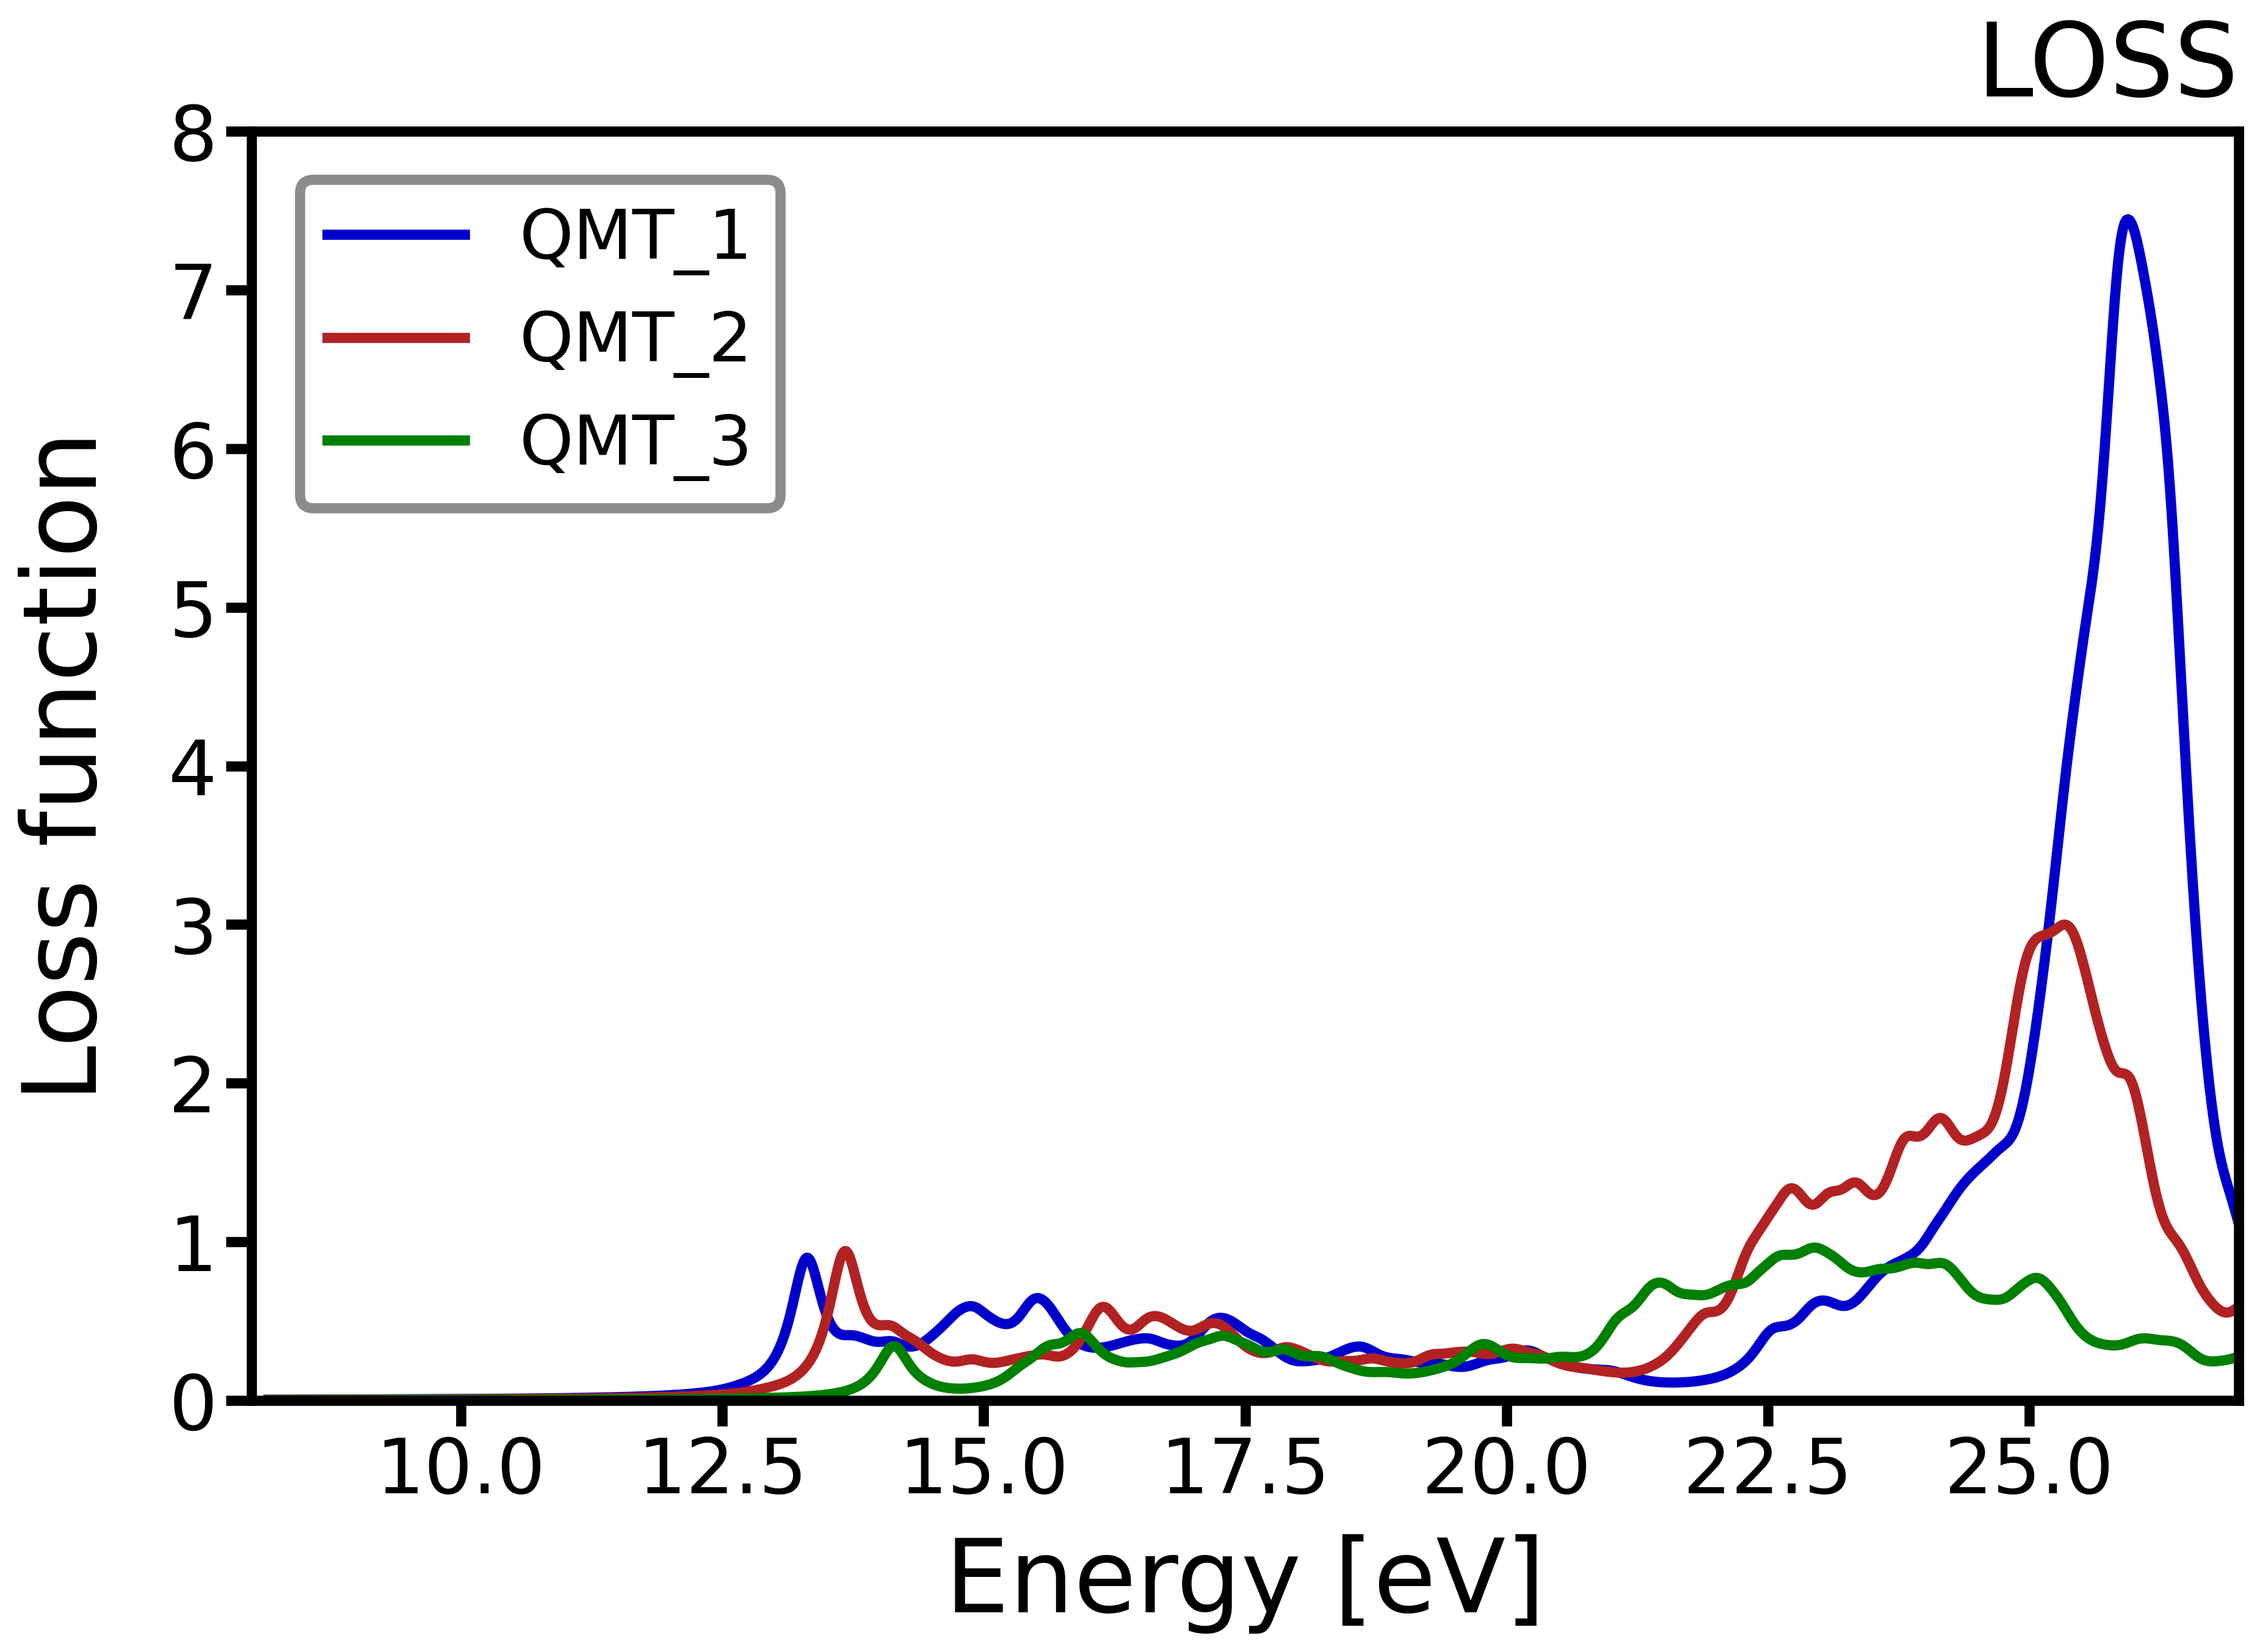" width="600" align="left"/>
</figure>

Notice that increasing the transferred momentum shifts the first peak to higher energies and reduces the oscillator strength. The pronounced maximum above 25 eV, which dominates the spectrum in the optical limit, is quenched at finite momentum transfer.

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">4. X-Ray BSE Calculation for Finite Momentum Values </span>

Equivalently to the calculation of the optical loss function above, we will now calculate the core loss function for excitations from the F *1s* states, *i.e.*, the F K edge of LiF. It is assumed that you are already familiar with this type of excited-state calculations, having performed the tutorial **X-ray Absorption Spectra Using BSE**. We move back to the parent directory **LiF-BSE-q** directory and create a new sub-directory **NRIXS**.

In [24]:
%%bash
cd run_LiF_BSE_q
mkdir -p NRIXS

As usual, we need to copy files from the **GS** folder into the **NRIXS** one, to avoid repeating the ground-state calculation.

In [25]:
%%bash
cd run_LiF_BSE_q/NRIXS
cp ../GS/{STATE.OUT,EFERMI.OUT,input.xml} ./
cd ../..

The ground-state calculation is skipped by setting <code><span style="color:mediumblue">do</span>=<span style="color:firebrick">"skip"</span></code> in the <code><span style="color:green">groundstate</span></code> element of the input file. Then, we add the following <code><span style="color:green">xs</span></code> subelement into the input file:
```xml
...
   <xs 
      xstype="BSE" 
      ngridk="4 4 4" 
      vkloff="0.097 0.273 0.493"
      ngridq="4 4 4"
      nempty="30"
      gqmax="3.0"
      broad="0.007"
      scissor="0.20947"
      tevout="true">
 
      <energywindow 
         intv="0.3 1.0" 
         points="1200"/>
 
      <screening 
         screentype="full"
         nempty="100"/>
 
      <BSE 
         bsetype="singlet"
         nstlbse="1 5 1 4"
         iqmtrange="1 3"/>
 
      <qpointset>
         <qpoint>0.00 0.0 0.00</qpoint>
         <qpoint>0.25 0.0 0.25</qpoint>
         <qpoint>0.50 0.0 0.50</qpoint>
      </qpointset>
 
   </xs>                 
...
     
```

The input file is nearly identical to the one used for optical calculations above. We have simply added the attribute <code><span style="color:mediumblue">xas</span></code> to trigger a core-level calculation, and we have specified which core states we want to excite using the attributes <code><span style="color:mediumblue">xasspecies</span></code>, <code><span style="color:mediumblue">xasatom</span></code>, and <code><span style="color:mediumblue">xasedge</span></code>. The range of unoccupied states is now defined by the attribute <code><span style="color:mediumblue">nstlxas</span></code>. Note that we also have to modify the attribute <code><span style="color:mediumblue">energywindow</span></code>, since core excitations occur at much higher energies than the optical ones.

In [26]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingXSInput

parsed_input = ExcitingInputXML.from_xml('./run_LiF_BSE_q/NRIXS/input.xml')

xs = {'xstype': 'BSE', 'ngridk': [4, 4, 4], 'vkloff': [0.097, 0.273, 0.493], 'ngridq': [4, 4, 4], 'nempty': 30,
      'gqmax': 3.0, 'broad': 0.007, 'scissor': 0.20947, 'tevout': True,
      'energywindow': {'intv': [24.0, 28.0], 'points': 1200},
      'screening': {'screentype': 'full', 'nempty': 100},
      'BSE': {'bsetype': 'singlet','xas': True, 'xasspecies': 1, 'xasatom': 1, 'nstlxas': [1, 4], 'iqmtrange': [1, 3]},
      'qpointset': [[0.0, 0.0, 0.0], [0.25, 0.0, 0.25], [0.5, 0.0, 0.5]]}

parsed_input.xs = ExcitingXSInput(**xs)
parsed_input.groundstate.do = "skip"

parsed_input.write('./run_LiF_BSE_q/NRIXS/input.xml')

Run the **BSE** calculation with the following commands:

In [27]:
%%bash
cd run_LiF_BSE_q/NRIXS
time $EXCITINGROOT/install/bin/exciting_smp input.xml
cd ../..

 ### Using specified input file: input.xml


   Elapsed time = 12m41s


After the run is successfully completed (it will take a few minutes), the usual output files and sub-folders will appear in the working directory.

Again, we are interested in the loss function, which is found inside the folder **LOSS**. The calculated loss function can be visualized from your command line with the same script used above:

In [28]:
%%bash
cd run_LiF_BSE_q/NRIXS
cp LOSS/LOSS_BSE-singlet-TDA-BAR_SCR-full_OC11.OUT   LOSS/QMT_1
cp LOSS/LOSS_BSE-singlet-TDA-BAR_SCR-full_QMT002.OUT LOSS/QMT_2
cp LOSS/LOSS_BSE-singlet-TDA-BAR_SCR-full_QMT003.OUT LOSS/QMT_3
python3 -m excitingscripts.plot.files -d LOSS  -f QMT_1 QMT_2 QMT_3  -lx 'Energy [eV]'  -ly 'Loss function'  -x 655 675

<figure>
<img src=" 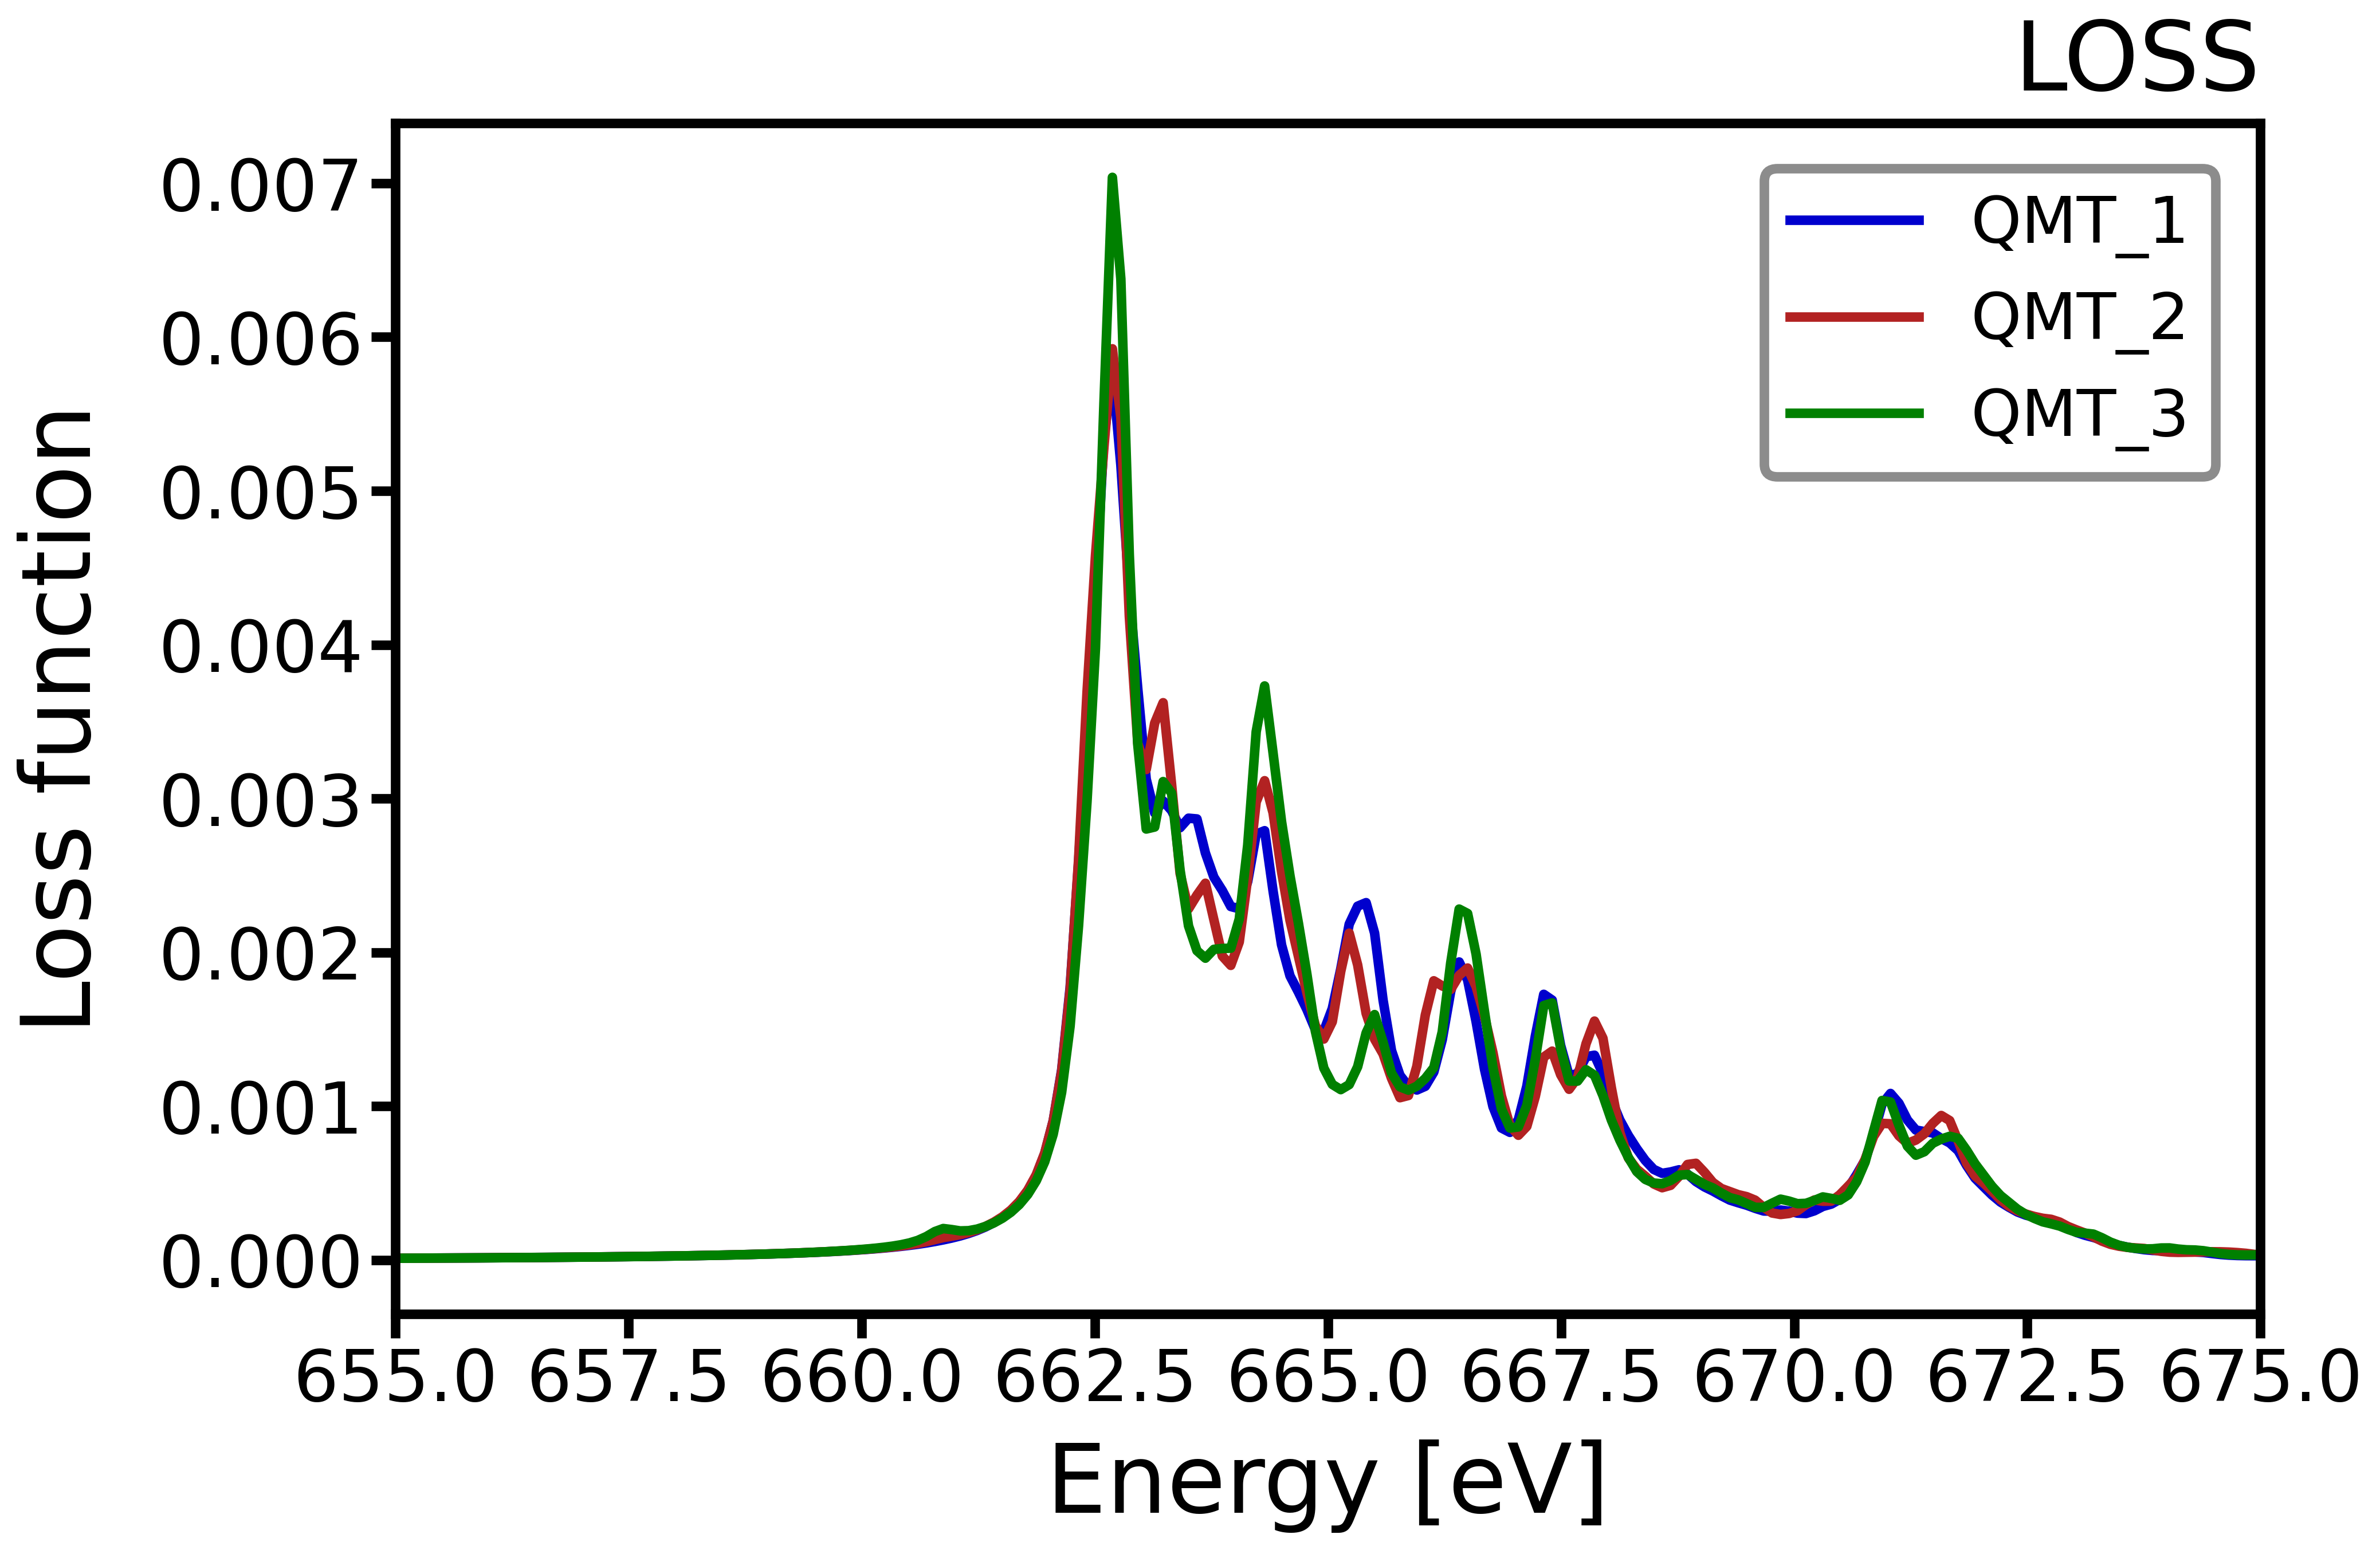" width="600" align="left"/>
</figure>

We observe less dependence of the loss function on momentum transfer than we saw in the previous case for the optical region. The most relevant changes in the spectrum with increasing momentum transfer are the emergence of a pre-peak that is dark at **q** = 0 and the increasing intensity of the first strong peak.

<a id='5'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">5. Exercise</span>

- Modify the attribute <code><span style="color:mediumblue">bsetype</span></code> to calculate the independent-particle (**IP**), random-phase approximation **RPA** and **triplet** loss function spectrum in the optical range for LiF. How is the spectrum modified? If you have already computed the **singlet** spectra, you only need to execute the last task of the **BSE** program flow, *i.e.*, **"bse"**, when switching the <code><span style="color:mediumblue">bsetype</span></code>.

<hr style="border:2px solid #DDD"> </hr>